# Figure2_2

In [1]:
from pathlib import Path

FIGURE_OUTPUT_DIR = Path("results/Figure2")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functions.load_data import loadTrialsM
from functions.utils import index_in, first_trials_by_image
from functions.plotting import set_paper_theme

set_paper_theme()


## Panel C — Category-wise generalization

In [3]:
df = pd.read_excel("data_behavior/THINGS_categories.xlsx", sheet_name="Categories")
catname = [column for column in df.columns
           if column != "category" and not column.endswith("_is_training_category")]
catid = df[catname].values


In [4]:

category_acc = {}
for task in ["Large_animate_vs_inanimate","Large_mammal_vs_nonmammal","Large_natural_vs_artificial"]:
    cr_monkey = []
    se_monkey = []
    for monkey in ["Elsa","Judy","Olaf"]:
        trials,files = loadTrialsM(task,monkey,verbose=True)
        trials_stim,_ = first_trials_by_image([tr for tr in trials if tr["trial_type"]=="gen"])
        # data property
        category = [tr["img_url"].split("/")[-2] for tr in trials_stim]
        results = np.array([tr["result"] for tr in trials_stim])
        line = np.array(index_in(category,df.category))

        # split by category
        results_cat = [[] for _ in range(len(catname))]
        for i in range(len(results)):
            for key,value in enumerate(catid[line[i],:]):
                if value==1:
                    results_cat[key].append(results[i])

        cr,se = [],[]
        for i in range(len(catname)):
            p = np.mean(np.array(results_cat[i])=="CORRECT")
            cr.append(p)
            se.append(np.sqrt(p*(1-p)/len(results_cat[i])))

        cr_monkey.append(cr)
        se_monkey.append(se)

    category_acc[task] = (np.mean(cr_monkey,axis=0), np.mean(se_monkey,axis=0))

cr_average_1,se_average_1 = category_acc["Large_animate_vs_inanimate"]
cr_average_2,se_average_2 = category_acc["Large_mammal_vs_nonmammal"]
cr_average_3,se_average_3 = category_acc["Large_natural_vs_artificial"]


data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231128_01_fmt.mat Trials Num:1119
data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231129_01_fmt.mat Trials Num:856
data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231130_01_fmt.mat Trials Num:909
data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231201_01_fmt.mat Trials Num:951
data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231202_01_fmt.mat Trials Num:927
data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231204_01_fmt.mat Trials Num:1016
data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231205_01_fmt.mat Trials Num:1051
data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231206_01_fmt.mat Trials Num:825
data_behavior/Monkey/Large_animate_vs_inanimate/Elsa20231207_01_fmt.mat Trials Num:1176
data_behavior/Monkey/Large_animate_vs_inanimate/Judy20231213_01_fmt.mat Trials Num:743
data_behavior/Monkey/Large_animate_vs_inanimate/Judy20231214_01_fmt.mat Trials Num:703
data_behavior/Monkey/Large_animate_vs_i

F:\Anaconda\envs\plot\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
F:\Anaconda\envs\plot\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


data_behavior/Monkey/Large_mammal_vs_nonmammal/Judy20240126_01_fmt.mat Trials Num:1316
data_behavior/Monkey/Large_mammal_vs_nonmammal/Judy20240127_01_fmt.mat Trials Num:1064
data_behavior/Monkey/Large_mammal_vs_nonmammal/Judy20240129_01_fmt.mat Trials Num:1422
data_behavior/Monkey/Large_mammal_vs_nonmammal/Judy20240130_01_fmt.mat Trials Num:1243
data_behavior/Monkey/Large_mammal_vs_nonmammal/Judy20240131_01_fmt.mat Trials Num:1232


F:\Anaconda\envs\plot\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
F:\Anaconda\envs\plot\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


data_behavior/Monkey/Large_mammal_vs_nonmammal/Olaf20231228_01_fmt.mat Trials Num:87
data_behavior/Monkey/Large_mammal_vs_nonmammal/Olaf20231228_02_fmt.mat Trials Num:1003
data_behavior/Monkey/Large_mammal_vs_nonmammal/Olaf20231229_01_fmt.mat Trials Num:536
data_behavior/Monkey/Large_mammal_vs_nonmammal/Olaf20240101_01_fmt.mat Trials Num:1076
data_behavior/Monkey/Large_mammal_vs_nonmammal/Olaf20240102_01_fmt.mat Trials Num:1218


...

F:\Anaconda\envs\plot\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
F:\Anaconda\envs\plot\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


data_behavior/Monkey/Large_natural_vs_artificial/Judy20240108_01_fmt.mat Trials Num:475
data_behavior/Monkey/Large_natural_vs_artificial/Judy20240109_01_fmt.mat Trials Num:889
data_behavior/Monkey/Large_natural_vs_artificial/Judy20240110_01_fmt.mat Trials Num:508
data_behavior/Monkey/Large_natural_vs_artificial/Judy20240111_01_fmt.mat Trials Num:801
data_behavior/Monkey/Large_natural_vs_artificial/Judy20240112_01_fmt.mat Trials Num:678
data_behavior/Monkey/Large_natural_vs_artificial/Judy20240113_01_fmt.mat Trials Num:865
data_behavior/Monkey/Large_natural_vs_artificial/Judy20240115_01_fmt.mat Trials Num:816


F:\Anaconda\envs\plot\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
F:\Anaconda\envs\plot\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


data_behavior/Monkey/Large_natural_vs_artificial/Olaf20231214_01_fmt.mat Trials Num:1215
data_behavior/Monkey/Large_natural_vs_artificial/Olaf20231215_01_fmt.mat Trials Num:1176
data_behavior/Monkey/Large_natural_vs_artificial/Olaf20231218_01_fmt.mat Trials Num:1153
data_behavior/Monkey/Large_natural_vs_artificial/Olaf20231219_01_fmt.mat Trials Num:1229


F:\Anaconda\envs\plot\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
F:\Anaconda\envs\plot\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [5]:
sorted_catname = [
    'Animal',
    'Mammal',
    'Non_mammal',
    'Reptile_Amphibian',
    'Bird',
    'Insect',
    'Fish',
    'Mollusks_Crustaceans',
    'Natural',
    'Artificial',
    'Plant',
    'Food',
    'Vegetable',
    'Fruit',
    'Tool',
    'Container',
    'Kitchen_tool',
    'Office_supply',
    'Electronic_device',
    'Kitchen_appliance',
    'Vehicle',
]

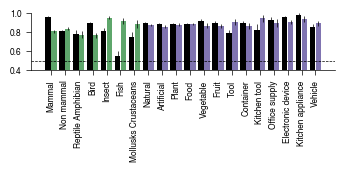

In [6]:
idx = index_in(sorted_catname,catname)
catname_p = [cat.replace("_"," ") for cat in sorted_catname]
cr1 = cr_average_1[idx][1:]
se1 = se_average_1[idx][1:]
cat = catname_p[1:]

cr2 = cr_average_2[idx][1:8]
se2 = se_average_2[idx][1:8]
cr3 = cr_average_3[idx][8:]
se3 = se_average_3[idx][8:]


fig, ax = plt.subplots()
fig.set(figheight=120/75,figwidth=250/75)

barwidth = 0.4
gap = 0.01

ax.bar(np.array(range(len(cr1)))-0.2-gap,cr1,color="black",width=0.4,yerr=se1,error_kw={"linewidth":0.5})
ax.bar(np.array(range(7))+0.2+gap,cr2,color="#5EA66B",width=0.4,yerr=se2,error_kw={"linewidth":0.5})
ax.bar(np.array(range(7,20))+0.2+gap,cr3,color="#8074B1",width=0.4,yerr=se3,error_kw={"linewidth":0.5})

ax.axhline(0.5,linestyle='--',color="black",linewidth=0.5)

ax.set_ylim(0.4,1)
ax.set_xticks(range(len(cat)),cat,rotation=90)

plt.savefig(FIGURE_OUTPUT_DIR / "generalization_by_category.pdf")
plt.show()